In [1]:
# ============================================
# 01. Setup
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
book_dir = Path("/mnt/f/book")
languages = ["english", "french", "german"]

books = pd.DataFrame([
    {"language": lang, "book": path.stem, "path": path}
    for lang in languages
    for path in sorted((book_dir / lang).glob("*.txt"))
])

display(books)

,language,book,path
0,english,alice,/mnt/f/book/english/alice.txt
1,english,mobydick,/mnt/f/book/english/mobydick.txt
2,english,pride,/mnt/f/book/english/pride.txt
3,english,sherlock,/mnt/f/book/english/sherlock.txt
4,french,candide,/mnt/f/book/french/candide.txt
5,french,madame_bovary,/mnt/f/book/french/madame_bovary.txt
6,french,notre_dame,/mnt/f/book/french/notre_dame.txt
7,german,faust,/mnt/f/book/german/faust.txt
8,german,kafka_verwandlung,/mnt/f/book/german/kafka_verwandlung.txt
9,german,nietzsche_zarathustra,/mnt/f/book/german/nietzsche_zarathustra.txt


In [3]:
# ============================================
# 02. Sequence length
# ============================================

books["n_char"] = books["path"].apply(lambda p: len(p.read_text().strip()))

display(books[["language", "book", "n_char"]])
display(books.groupby("language")["n_char"].agg(["count", "mean", "min", "max"]).round(0))

,language,book,n_char
0,english,alice,163948
1,english,mobydick,1238277
2,english,pride,748165
3,english,sherlock,581599
4,french,candide,220804
5,french,madame_bovary,677684
6,french,notre_dame,1189469
7,german,faust,207095
8,german,kafka_verwandlung,141032
9,german,nietzsche_zarathustra,538591


,count,mean,min,max
language,,,,
english,4,682997.0,163948,1238277
french,3,695986.0,220804,1189469
german,3,295573.0,141032,538591


In [17]:
# ============================================
# 03. Load k-mer counts
# ============================================

kmer_dir = Path("../results/kmers")

kmer = {}
for k in range(1, 7):
    kmer[k] = pd.read_csv(kmer_dir / f"k{k}_book_counts.tsv", sep="\t")
    print(f"k={k}: {kmer[k].shape}")

display(kmer[2].head())

k=1: (572, 6)
k=2: (11822, 6)
k=3: (121306, 6)
k=4: (646290, 6)
k=5: (1799938, 6)
k=6: (3249516, 6)


,language,book,k,kmer,count,frequency
0,dutch,camera_obscura,2,PR,398,0.001094
1,dutch,camera_obscura,2,RO,2287,0.006286
2,dutch,camera_obscura,2,OD,709,0.001949
3,dutch,camera_obscura,2,DU,276,0.000759
4,dutch,camera_obscura,2,UC,486,0.001336


In [18]:
# ============================================
# 01. Balanced dataset
# ============================================

keep_books = {
    "english": ["alice", "pride", "sherlock"],
    "french": ["candide", "madame_bovary", "notre_dame"],
    "german": ["faust", "kafka_verwandlung", "nietzsche_zarathustra"],
}

data = {}
for k in [1, 2, 3]:
    df = kmer[k].query("language in @languages").copy()
    data[k] = df[df.apply(lambda x: x["book"] in keep_books[x["language"]], axis=1)]

for k, df in data.items():
    print(f"k={k}: {df['book'].nunique()} books | frequency sum/book:",
          df.groupby(["language", "book"])["frequency"].sum().round(3).unique())

k=1: 9 books | frequency sum/book: [1.]
k=2: 9 books | frequency sum/book: [1.]
k=3: 9 books | frequency sum/book: [1.]


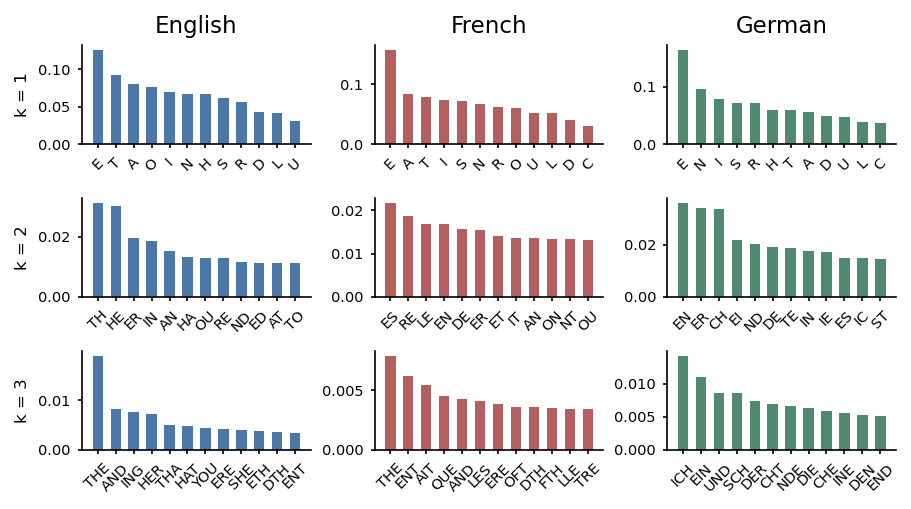

In [34]:
# ============================================
# 02. Mean k-mer profiles by language
# ============================================

colors = {"english": "#4C78A8", "french": "#B45F5F", "german": "#4F8A70"}

fig, axes = plt.subplots(3, 3, figsize=(7, 3.5), dpi=150)

for col, lang in enumerate(languages):
    for row, k in enumerate([1, 2, 3]):
        ax = axes[row, col]
        s = data[k].query("language == @lang").groupby("kmer")["frequency"].mean().nlargest(12)

        ax.bar(s.index, s.values, width=0.58, color=colors[lang])
        ax.tick_params(axis="x", rotation=45, labelsize=7, length=2)
        ax.tick_params(axis="y", labelsize=7, length=2)
        ax.spines[["top", "right"]].set_visible(False)

        if row == 0: ax.set_title(lang.capitalize(), fontsize=11)
        if col == 0: ax.set_ylabel(f"k = {k}", fontsize=8)

fig.subplots_adjust(wspace=0.28, hspace=0.55)
plt.show()